# Experiment: LLM-Suggested Feature
Feature formula: Exercise_Stress_Index = Oldpeak + (ExerciseAngina × ST_Slope_Up

# 1. Setup

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score


train = pd.read_csv("../1-Data/train_processed.csv")
x_train_before = train.drop(columns=["HeartDisease"])
y_train = train["HeartDisease"]

test = pd.read_csv("../1-Data/test_processed.csv")
x_test_before = test.drop(columns=["HeartDisease"])
y_test = test["HeartDisease"]


CHOSEN_C = 0.01
CHOSEN_THRESHOLD = 0.45

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

Train shape: (733, 16)
Test shape:  (184, 16)


# 2. Before feature

In [18]:
model_before = LogisticRegression(C=CHOSEN_C, random_state=42, max_iter=1000)
model_before.fit(x_train_before, y_train)

y_proba_before = model_before.predict_proba(x_test_before)[:, 1]
y_pred_before  = (y_proba_before >= CHOSEN_THRESHOLD).astype(int)

print("Classification Report BEFORE Feature:")
print(classification_report(y_test, y_pred_before, target_names=["Normal", "Heart Disease"]))
print(f"Accuracy: {accuracy_score(y_test, y_pred_before):.4f}")

Classification Report BEFORE Feature:
               precision    recall  f1-score   support

       Normal       0.91      0.83      0.87        82
Heart Disease       0.87      0.93      0.90       102

     accuracy                           0.89       184
    macro avg       0.89      0.88      0.88       184
 weighted avg       0.89      0.89      0.89       184

Accuracy: 0.8859


# 3. Add feature

In [19]:
x_train_after = x_train_before.copy()
x_test_after = x_test_before.copy()

# Implement the Exercise Stress Index formula suggested by the LLM
# Formula: Oldpeak + (ExerciseAngina * ST_Slope_Up)
x_train_after["Exercise_Stress_Index"] = x_train_after["Oldpeak"] + (x_train_after["ExerciseAngina"] * x_train_after["ST_Slope_Up"])
x_test_after["Exercise_Stress_Index"] = x_test_after["Oldpeak"] + (x_test_after["ExerciseAngina"] * x_test_after["ST_Slope_Up"])

print(f"Features before: {x_train_before.shape[1]}")
print(f"Features after:  {x_train_after.shape[1]}  (+1 Exercise_Stress_Index)")
print(f"\nSample values of new feature (first 5 rows):")
print(x_train_after["Exercise_Stress_Index"].head())

Features before: 15
Features after:  16  (+1 Exercise_Stress_Index)

Sample values of new feature (first 5 rows):
0   -1.874044
1    0.586428
2    1.958446
3    0.088123
4    0.463859
Name: Exercise_Stress_Index, dtype: float64


# 4. After feature

In [20]:
model_after = LogisticRegression(C=CHOSEN_C, random_state=42, max_iter=1000)
model_after.fit(x_train_after, y_train)

y_proba_after = model_after.predict_proba(x_test_after)[:, 1]
y_pred_after = (y_proba_after >= CHOSEN_THRESHOLD).astype(int)
acc_after = accuracy_score(y_test, y_pred_after)


print("Classification Report AFTER Feature:")
print(classification_report(y_test, y_pred_after, target_names=["Normal", "Heart Disease"]))
print(f"Accuracy: {accuracy_score(y_test, y_pred_after):.4f}")

Classification Report AFTER Feature:
               precision    recall  f1-score   support

       Normal       0.90      0.79      0.84        82
Heart Disease       0.85      0.93      0.89       102

     accuracy                           0.87       184
    macro avg       0.88      0.86      0.87       184
 weighted avg       0.87      0.87      0.87       184

Accuracy: 0.8696


# 5. Result Comparison

In [21]:
def get_hd_metrics(y_true, y_pred):
    report = classification_report(
        y_true, y_pred,
        target_names=["Normal", "Heart Disease"],
        output_dict=True
    )
    hd = report["Heart Disease"]
    return {
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": hd["precision"],
        "Recall"   : hd["recall"],
        "F1-Score" : hd["f1-score"]
    }

m_before = get_hd_metrics(y_test, y_pred_before)
m_after  = get_hd_metrics(y_test, y_pred_after)

#summary table
summary = pd.DataFrame([m_before, m_after],
                       index=["Before Feature", "After Feature"]).round(4)
print("   CONTROLLED EXPERIMENT: EXERCISE STRESS INDEX")
print(summary.to_string())
diff = summary.loc["After Feature"] - summary.loc["Before Feature"]
print("Delta (After - Before):")
for col in diff.index:
    sign = "+" if diff[col] >= 0 else ""
    print(f"  {col:<12}: {sign}{diff[col]:.4f}")

   CONTROLLED EXPERIMENT: EXERCISE STRESS INDEX
                Accuracy  Precision  Recall  F1-Score
Before Feature    0.8859     0.8716  0.9314    0.9005
After Feature     0.8696     0.8482  0.9314    0.8879
Delta (After - Before):
  Accuracy    : -0.0163
  Precision   : -0.0234
  Recall      : +0.0000
  F1-Score    : -0.0126


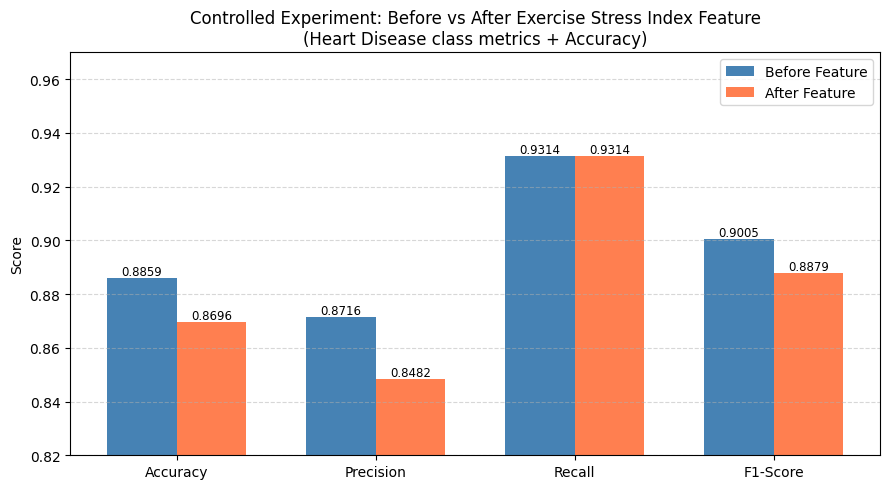

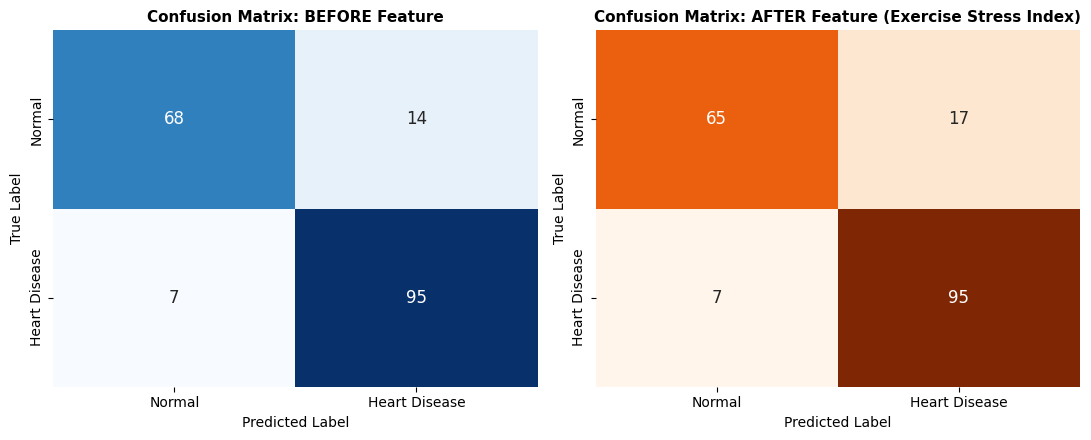

In [22]:
# ── Chart 1: Grouped bar chart — Before vs After ──────────────
metrics   = ["Accuracy", "Precision", "Recall", "F1-Score"]
vals_before = [m_before[m] for m in metrics]
vals_after  = [m_after[m]  for m in metrics]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, vals_before, width,
               label="Before Feature", color="steelblue")
bars2 = ax.bar(x + width/2, vals_after,  width,
               label="After Feature",  color="coral")

for bar in bars1:
    ax.annotate(f"{bar.get_height():.4f}",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=8.5)
for bar in bars2:
    ax.annotate(f"{bar.get_height():.4f}",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.82, 0.97)
ax.set_ylabel("Score")
ax.set_title("Controlled Experiment: Before vs After Exercise Stress Index Feature\n(Heart Disease class metrics + Accuracy)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("performance_comparison.png", dpi=300)
plt.show()

# ── Chart 2: Side-by-side confusion matrices ──────────────────
cm_before = confusion_matrix(y_test, y_pred_before)
cm_after  = confusion_matrix(y_test, y_pred_after)

fig2, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.heatmap(cm_before, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Normal", "Heart Disease"],
            yticklabels=["Normal", "Heart Disease"],
            ax=axes[0], annot_kws={"size": 12})
axes[0].set_title("Confusion Matrix: BEFORE Feature",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(cm_after, annot=True, fmt="d", cmap="Oranges", cbar=False,
            xticklabels=["Normal", "Heart Disease"],
            yticklabels=["Normal", "Heart Disease"],
            ax=axes[1], annot_kws={"size": 12})
axes[1].set_title("Confusion Matrix: AFTER Feature (Exercise Stress Index)",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=300)
plt.show()

# 6. Reflection

## 6.1. Why the Feature Did Not Improve Performance  
Despite strong clinical justification, adding the Exercise Stress Index actively degraded the model. As the experiment shows, Accuracy dropped by 0.0163, Precision by 0.0234, and the F1-Score by 0.0126, while Recall remained completely stagnant. Two reasons explain this decline:  

1. Mathematical distortion of standardized space The dataset was Z-score standardized prior to feature engineering. The formula multiplies two standardized binary values (ExerciseAngina and ST_Slope_Up). Because Z-scores include negative values for patients below the mean, multiplying two negative (low-risk) values produces a positive product. This destroys the directional meaning that Logistic Regression relies on.

2. Feature redundancy The index aggregates Oldpeak, ExerciseAngina, and ST_Slope_Up—all of which already exist in the dataset. Logistic Regression inherently learns to weight these independent features optimally. Forcing them into a single interaction term adds noise rather than novel information.

## 6.2 What does this tell us about LLM-Assisted Engineering
- The LLM served as a strong clinical advisor. It correctly identified that these specific stress test components are medically interconnected and formulated a sound clinical hypothesis.

- However, the LLM lacked mathematical and pipeline context. It failed to account for the pre-applied Z-score standardization and the additive mechanics of Logistic Regression.

--> Conclusion: LLMs are highly effective for generating domain-specific hypotheses, but their suggestions must be strictly evaluated against the mathematical realities of the specific data pipeline. Clinical validity does not guarantee computational effectiveness.